In [3]:
from IPython.display import display, HTML
display(HTML("""
<style>
div.container{width:95% !important;}
div.cell.code_cell.rendered{width:95%;}
div.input_prompt{padding:0px;}
div.CodeMirror {font-family:Consolas; font-size:20pt;}
.inner_cell{font-size:20pt;}
div.text_cell_render pre code {font-size:20pt; line-height:30px;}
div.output {font-size:20pt; font-weight:bold;}
div.input {font-family:Consolas; font-size:20pt;}
div.prompt {min-width:70px;}
div#toc-wrapper{padding-top:120px;}
div.text_cell_render ul li{font-size:20pt;padding:5px;}
table.dataframe{font-size:20px;}
</style>
"""))

In [5]:
# GPU 활성화 끄기
import os
os.environ['CUDA_VISIBLE_DEVICES'] = "-1"
# GPU 사용 여부 확인
import tensorflow as tf
print(tf.__version__)
tf.config.list_physical_devices('GPU')

2.10.0


[]

# 1. 기존의 프로그램 방식

In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# 섭씨온도(input data)를 받아 화씨 온도로 출력
def celsius_to_faherenheit(c):
    return 1.8*c + 32

In [9]:
input_data = int(input('섭씨온도는?'))
print('화씨온도는', celsius_to_faherenheit(input_data))

섭씨온도는?0
화씨온도는 32.0


# 2. 머신러닝/딥러닝 프로그램 방식
- 1. 데이터 확보 및 생성
- 2. 데이터 전처리 : scale조정, 라벨링처리, 훈련데이터셋(학습데이터셋), 검증데이터셋, 시험데이터셋으로 나누기
- 3. 모델구성
- 4. 모델 학습과정 설정
- 5. 모델 학습시키기(학습데이터셋과 검증데이터셋으로)
- 6. 모델 평가(시험데이터셋으로)
- 7. 모델 사용(입력값이 주어지면 예측값을 받기)
## 2.1 노이즈가 없는 데이터로 실습

In [10]:
# 1. 데이터 생성
data_C = np.arange(100)
data_C # 입력변수==독립변수

array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33,
       34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50,
       51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67,
       68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84,
       85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99])

In [11]:
data_F = celsius_to_faherenheit(data_C)
data_F # 타겟변수==종속변수

array([ 32. ,  33.8,  35.6,  37.4,  39.2,  41. ,  42.8,  44.6,  46.4,
        48.2,  50. ,  51.8,  53.6,  55.4,  57.2,  59. ,  60.8,  62.6,
        64.4,  66.2,  68. ,  69.8,  71.6,  73.4,  75.2,  77. ,  78.8,
        80.6,  82.4,  84.2,  86. ,  87.8,  89.6,  91.4,  93.2,  95. ,
        96.8,  98.6, 100.4, 102.2, 104. , 105.8, 107.6, 109.4, 111.2,
       113. , 114.8, 116.6, 118.4, 120.2, 122. , 123.8, 125.6, 127.4,
       129.2, 131. , 132.8, 134.6, 136.4, 138.2, 140. , 141.8, 143.6,
       145.4, 147.2, 149. , 150.8, 152.6, 154.4, 156.2, 158. , 159.8,
       161.6, 163.4, 165.2, 167. , 168.8, 170.6, 172.4, 174.2, 176. ,
       177.8, 179.6, 181.4, 183.2, 185. , 186.8, 188.6, 190.4, 192.2,
       194. , 195.8, 197.6, 199.4, 201.2, 203. , 204.8, 206.6, 208.4,
       210.2])

In [13]:
# 2. 데이터 전처리 : 컴퓨터에게 학습시키기 위해, Normalize함(변수들의 편차를 비슷하게)
scaled_data_C = data_C/100.0
scaled_data_F = data_F/100.0
print('독립변수는 ', scaled_data_C)
print('종속변수는 ', scaled_data_F)

독립변수는  [0.   0.01 0.02 0.03 0.04 0.05 0.06 0.07 0.08 0.09 0.1  0.11 0.12 0.13
 0.14 0.15 0.16 0.17 0.18 0.19 0.2  0.21 0.22 0.23 0.24 0.25 0.26 0.27
 0.28 0.29 0.3  0.31 0.32 0.33 0.34 0.35 0.36 0.37 0.38 0.39 0.4  0.41
 0.42 0.43 0.44 0.45 0.46 0.47 0.48 0.49 0.5  0.51 0.52 0.53 0.54 0.55
 0.56 0.57 0.58 0.59 0.6  0.61 0.62 0.63 0.64 0.65 0.66 0.67 0.68 0.69
 0.7  0.71 0.72 0.73 0.74 0.75 0.76 0.77 0.78 0.79 0.8  0.81 0.82 0.83
 0.84 0.85 0.86 0.87 0.88 0.89 0.9  0.91 0.92 0.93 0.94 0.95 0.96 0.97
 0.98 0.99]


In [16]:
# 3. 모델 구성(tensorflow)
from tensorflow.keras.models import Sequential # 모델 생성
from tensorflow.keras.layers import Dense # 입력값과 출력값으로 layer층 지정
model = Sequential()
model.add(Dense(1, # 출력(종속, 타겟)변수의 갯수
               input_shape=(1,) # 입력(독립)변수의 shape
               ))
print(model.summary())

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense (Dense)               (None, 1)                 2         
                                                                 
Total params: 2
Trainable params: 2
Non-trainable params: 0
_________________________________________________________________
None


- 회귀분석 오차함수 : 
  MSE(오차제곱평균), RMSE(루트를 취하기 때문에 MSE단점이 어느정도 해소, 덜 민감), MAE(절대값평균)

In [22]:
# 4. 모델 학습 과정 설정
model.compile(loss='mse', optimizer='rmsprop', metrics=['mae'])
             # 손실함수            옵티마이저        평가지표
# loss(오차, 손실함수)는 모델 학습 중 최적화할 대상
# metrics : 평가지표 

In [23]:
# 학습 전 예측
model.predict(np.array([[0],
                       [0.01]]))

1/1 [==============================] - 0s 74ms/step


array([[ 0.        ],
       [-0.00601945]], dtype=float32)

In [24]:
# 학습 전 모델 저장
model.save('model/before_learning.h5') # kernel에 w(기울기), bias에 b이 있음
# from tensorflow.keras.models import save_model
# save_model(model, 'model/before_learning.h5')

In [25]:
# 모델 학습시키기 - 1번만 실행
hist = model.fit(scaled_data_C, scaled_data_F, epochs=1000, verbose=2)
                 #  독립변수      타겟변수(종속)    학습횟수    학습시출력여부

Epoch 1/1000
4/4 - 1s - loss: 2.7430 - mae: 1.5045 - 504ms/epoch - 126ms/step
Epoch 2/1000
4/4 - 0s - loss: 2.7062 - mae: 1.4931 - 9ms/epoch - 2ms/step
Epoch 3/1000
4/4 - 0s - loss: 2.6808 - mae: 1.4852 - 7ms/epoch - 2ms/step
Epoch 4/1000
4/4 - 0s - loss: 2.6581 - mae: 1.4784 - 8ms/epoch - 2ms/step
Epoch 5/1000
4/4 - 0s - loss: 2.6357 - mae: 1.4713 - 6ms/epoch - 2ms/step
Epoch 6/1000
4/4 - 0s - loss: 2.6162 - mae: 1.4653 - 6ms/epoch - 2ms/step
Epoch 7/1000
4/4 - 0s - loss: 2.5959 - mae: 1.4589 - 6ms/epoch - 2ms/step
Epoch 8/1000
4/4 - 0s - loss: 2.5753 - mae: 1.4525 - 9ms/epoch - 2ms/step
Epoch 9/1000
4/4 - 0s - loss: 2.5562 - mae: 1.4463 - 7ms/epoch - 2ms/step
Epoch 10/1000
4/4 - 0s - loss: 2.5381 - mae: 1.4406 - 6ms/epoch - 1ms/step
Epoch 11/1000
4/4 - 0s - loss: 2.5187 - mae: 1.4345 - 9ms/epoch - 2ms/step
Epoch 12/1000
4/4 - 0s - loss: 2.5015 - mae: 1.4289 - 6ms/epoch - 1ms/step
Epoch 13/1000
4/4 - 0s - loss: 2.4827 - mae: 1.4229 - 6ms/epoch - 1ms/step
Epoch 14/1000
4/4 - 0s - loss:

4/4 - 0s - loss: 1.0599 - mae: 0.8662 - 9ms/epoch - 2ms/step
Epoch 111/1000
4/4 - 0s - loss: 1.0504 - mae: 0.8618 - 8ms/epoch - 2ms/step
Epoch 112/1000
4/4 - 0s - loss: 1.0404 - mae: 0.8570 - 7ms/epoch - 2ms/step
Epoch 113/1000
4/4 - 0s - loss: 1.0301 - mae: 0.8523 - 5ms/epoch - 1ms/step
Epoch 114/1000
4/4 - 0s - loss: 1.0184 - mae: 0.8466 - 6ms/epoch - 1ms/step
Epoch 115/1000
4/4 - 0s - loss: 1.0075 - mae: 0.8414 - 8ms/epoch - 2ms/step
Epoch 116/1000
4/4 - 0s - loss: 0.9962 - mae: 0.8360 - 6ms/epoch - 2ms/step
Epoch 117/1000
4/4 - 0s - loss: 0.9861 - mae: 0.8313 - 8ms/epoch - 2ms/step
Epoch 118/1000
4/4 - 0s - loss: 0.9764 - mae: 0.8265 - 7ms/epoch - 2ms/step
Epoch 119/1000
4/4 - 0s - loss: 0.9644 - mae: 0.8207 - 5ms/epoch - 1ms/step
Epoch 120/1000
4/4 - 0s - loss: 0.9542 - mae: 0.8158 - 7ms/epoch - 2ms/step
Epoch 121/1000
4/4 - 0s - loss: 0.9441 - mae: 0.8109 - 7ms/epoch - 2ms/step
Epoch 122/1000
4/4 - 0s - loss: 0.9323 - mae: 0.8051 - 7ms/epoch - 2ms/step
Epoch 123/1000
4/4 - 0s - l

Epoch 218/1000
4/4 - 0s - loss: 0.2678 - mae: 0.4317 - 7ms/epoch - 2ms/step
Epoch 219/1000
4/4 - 0s - loss: 0.2640 - mae: 0.4294 - 9ms/epoch - 2ms/step
Epoch 220/1000
4/4 - 0s - loss: 0.2603 - mae: 0.4265 - 5ms/epoch - 1ms/step
Epoch 221/1000
4/4 - 0s - loss: 0.2570 - mae: 0.4244 - 10ms/epoch - 3ms/step
Epoch 222/1000
4/4 - 0s - loss: 0.2533 - mae: 0.4217 - 7ms/epoch - 2ms/step
Epoch 223/1000
4/4 - 0s - loss: 0.2494 - mae: 0.4189 - 7ms/epoch - 2ms/step
Epoch 224/1000
4/4 - 0s - loss: 0.2462 - mae: 0.4167 - 7ms/epoch - 2ms/step
Epoch 225/1000
4/4 - 0s - loss: 0.2428 - mae: 0.4141 - 6ms/epoch - 2ms/step
Epoch 226/1000
4/4 - 0s - loss: 0.2392 - mae: 0.4116 - 6ms/epoch - 2ms/step
Epoch 227/1000
4/4 - 0s - loss: 0.2357 - mae: 0.4089 - 7ms/epoch - 2ms/step
Epoch 228/1000
4/4 - 0s - loss: 0.2331 - mae: 0.4071 - 9ms/epoch - 2ms/step
Epoch 229/1000
4/4 - 0s - loss: 0.2305 - mae: 0.4051 - 10ms/epoch - 2ms/step
Epoch 230/1000
4/4 - 0s - loss: 0.2276 - mae: 0.4030 - 6ms/epoch - 1ms/step
Epoch 231/

Epoch 326/1000
4/4 - 0s - loss: 0.1184 - mae: 0.2974 - 11ms/epoch - 3ms/step
Epoch 327/1000
4/4 - 0s - loss: 0.1178 - mae: 0.2967 - 6ms/epoch - 2ms/step
Epoch 328/1000
4/4 - 0s - loss: 0.1172 - mae: 0.2958 - 7ms/epoch - 2ms/step
Epoch 329/1000
4/4 - 0s - loss: 0.1165 - mae: 0.2949 - 7ms/epoch - 2ms/step
Epoch 330/1000
4/4 - 0s - loss: 0.1159 - mae: 0.2942 - 9ms/epoch - 2ms/step
Epoch 331/1000
4/4 - 0s - loss: 0.1151 - mae: 0.2933 - 6ms/epoch - 2ms/step
Epoch 332/1000
4/4 - 0s - loss: 0.1143 - mae: 0.2923 - 5ms/epoch - 1ms/step
Epoch 333/1000
4/4 - 0s - loss: 0.1136 - mae: 0.2914 - 7ms/epoch - 2ms/step
Epoch 334/1000
4/4 - 0s - loss: 0.1129 - mae: 0.2904 - 6ms/epoch - 1ms/step
Epoch 335/1000
4/4 - 0s - loss: 0.1124 - mae: 0.2897 - 7ms/epoch - 2ms/step
Epoch 336/1000
4/4 - 0s - loss: 0.1118 - mae: 0.2890 - 6ms/epoch - 2ms/step
Epoch 337/1000
4/4 - 0s - loss: 0.1110 - mae: 0.2880 - 8ms/epoch - 2ms/step
Epoch 338/1000
4/4 - 0s - loss: 0.1102 - mae: 0.2869 - 7ms/epoch - 2ms/step
Epoch 339/1

Epoch 434/1000
4/4 - 0s - loss: 0.0585 - mae: 0.2087 - 7ms/epoch - 2ms/step
Epoch 435/1000
4/4 - 0s - loss: 0.0580 - mae: 0.2078 - 7ms/epoch - 2ms/step
Epoch 436/1000
4/4 - 0s - loss: 0.0575 - mae: 0.2070 - 8ms/epoch - 2ms/step
Epoch 437/1000
4/4 - 0s - loss: 0.0569 - mae: 0.2060 - 7ms/epoch - 2ms/step
Epoch 438/1000
4/4 - 0s - loss: 0.0564 - mae: 0.2050 - 6ms/epoch - 2ms/step
Epoch 439/1000
4/4 - 0s - loss: 0.0559 - mae: 0.2042 - 8ms/epoch - 2ms/step
Epoch 440/1000
4/4 - 0s - loss: 0.0554 - mae: 0.2032 - 5ms/epoch - 1ms/step
Epoch 441/1000
4/4 - 0s - loss: 0.0549 - mae: 0.2023 - 7ms/epoch - 2ms/step
Epoch 442/1000
4/4 - 0s - loss: 0.0544 - mae: 0.2015 - 8ms/epoch - 2ms/step
Epoch 443/1000
4/4 - 0s - loss: 0.0539 - mae: 0.2005 - 5ms/epoch - 1ms/step
Epoch 444/1000
4/4 - 0s - loss: 0.0533 - mae: 0.1995 - 7ms/epoch - 2ms/step
Epoch 445/1000
4/4 - 0s - loss: 0.0529 - mae: 0.1986 - 5ms/epoch - 1ms/step
Epoch 446/1000
4/4 - 0s - loss: 0.0524 - mae: 0.1977 - 10ms/epoch - 2ms/step
Epoch 447/1

Epoch 542/1000
4/4 - 0s - loss: 0.0191 - mae: 0.1195 - 7ms/epoch - 2ms/step
Epoch 543/1000
4/4 - 0s - loss: 0.0189 - mae: 0.1187 - 11ms/epoch - 3ms/step
Epoch 544/1000
4/4 - 0s - loss: 0.0186 - mae: 0.1178 - 8ms/epoch - 2ms/step
Epoch 545/1000
4/4 - 0s - loss: 0.0183 - mae: 0.1169 - 7ms/epoch - 2ms/step
Epoch 546/1000
4/4 - 0s - loss: 0.0180 - mae: 0.1160 - 8ms/epoch - 2ms/step
Epoch 547/1000
4/4 - 0s - loss: 0.0177 - mae: 0.1150 - 8ms/epoch - 2ms/step
Epoch 548/1000
4/4 - 0s - loss: 0.0174 - mae: 0.1139 - 8ms/epoch - 2ms/step
Epoch 549/1000
4/4 - 0s - loss: 0.0172 - mae: 0.1133 - 5ms/epoch - 1ms/step
Epoch 550/1000
4/4 - 0s - loss: 0.0169 - mae: 0.1125 - 8ms/epoch - 2ms/step
Epoch 551/1000
4/4 - 0s - loss: 0.0167 - mae: 0.1118 - 9ms/epoch - 2ms/step
Epoch 552/1000
4/4 - 0s - loss: 0.0164 - mae: 0.1108 - 6ms/epoch - 2ms/step
Epoch 553/1000
4/4 - 0s - loss: 0.0162 - mae: 0.1099 - 8ms/epoch - 2ms/step
Epoch 554/1000
4/4 - 0s - loss: 0.0159 - mae: 0.1089 - 7ms/epoch - 2ms/step
Epoch 555/1

Epoch 650/1000
4/4 - 0s - loss: 0.0011 - mae: 0.0290 - 6ms/epoch - 2ms/step
Epoch 651/1000
4/4 - 0s - loss: 0.0011 - mae: 0.0283 - 5ms/epoch - 1ms/step
Epoch 652/1000
4/4 - 0s - loss: 0.0010 - mae: 0.0274 - 6ms/epoch - 2ms/step
Epoch 653/1000
4/4 - 0s - loss: 9.5671e-04 - mae: 0.0267 - 10ms/epoch - 3ms/step
Epoch 654/1000
4/4 - 0s - loss: 9.1056e-04 - mae: 0.0260 - 7ms/epoch - 2ms/step
Epoch 655/1000
4/4 - 0s - loss: 8.5062e-04 - mae: 0.0252 - 8ms/epoch - 2ms/step
Epoch 656/1000
4/4 - 0s - loss: 8.1107e-04 - mae: 0.0245 - 8ms/epoch - 2ms/step
Epoch 657/1000
4/4 - 0s - loss: 7.6134e-04 - mae: 0.0238 - 5ms/epoch - 1ms/step
Epoch 658/1000
4/4 - 0s - loss: 7.2163e-04 - mae: 0.0231 - 7ms/epoch - 2ms/step
Epoch 659/1000
4/4 - 0s - loss: 6.6650e-04 - mae: 0.0223 - 6ms/epoch - 2ms/step
Epoch 660/1000
4/4 - 0s - loss: 6.1976e-04 - mae: 0.0214 - 8ms/epoch - 2ms/step
Epoch 661/1000
4/4 - 0s - loss: 5.7758e-04 - mae: 0.0207 - 6ms/epoch - 2ms/step
Epoch 662/1000
4/4 - 0s - loss: 5.2803e-04 - mae: 0

Epoch 750/1000
4/4 - 0s - loss: 3.5601e-07 - mae: 5.8492e-04 - 6ms/epoch - 1ms/step
Epoch 751/1000
4/4 - 0s - loss: 4.4788e-07 - mae: 6.5564e-04 - 6ms/epoch - 1ms/step
Epoch 752/1000
4/4 - 0s - loss: 8.4133e-07 - mae: 8.9929e-04 - 6ms/epoch - 1ms/step
Epoch 753/1000
4/4 - 0s - loss: 6.1328e-07 - mae: 7.6533e-04 - 4ms/epoch - 998us/step
Epoch 754/1000
4/4 - 0s - loss: 3.5833e-08 - mae: 1.7878e-04 - 7ms/epoch - 2ms/step
Epoch 755/1000
4/4 - 0s - loss: 2.4681e-07 - mae: 4.5496e-04 - 7ms/epoch - 2ms/step
Epoch 756/1000
4/4 - 0s - loss: 1.7301e-06 - mae: 0.0013 - 7ms/epoch - 2ms/step
Epoch 757/1000
4/4 - 0s - loss: 5.4015e-07 - mae: 6.8965e-04 - 8ms/epoch - 2ms/step
Epoch 758/1000
4/4 - 0s - loss: 9.7618e-08 - mae: 2.9886e-04 - 8ms/epoch - 2ms/step
Epoch 759/1000
4/4 - 0s - loss: 2.6489e-07 - mae: 4.8177e-04 - 6ms/epoch - 2ms/step
Epoch 760/1000
4/4 - 0s - loss: 1.1983e-06 - mae: 0.0011 - 7ms/epoch - 2ms/step
Epoch 761/1000
4/4 - 0s - loss: 4.3333e-07 - mae: 6.3572e-04 - 6ms/epoch - 1ms/ste

Epoch 848/1000
4/4 - 0s - loss: 1.0617e-06 - mae: 0.0010 - 6ms/epoch - 2ms/step
Epoch 849/1000
4/4 - 0s - loss: 8.7354e-07 - mae: 8.6394e-04 - 7ms/epoch - 2ms/step
Epoch 850/1000
4/4 - 0s - loss: 8.1597e-08 - mae: 2.7665e-04 - 7ms/epoch - 2ms/step
Epoch 851/1000
4/4 - 0s - loss: 1.0457e-07 - mae: 3.0496e-04 - 7ms/epoch - 2ms/step
Epoch 852/1000
4/4 - 0s - loss: 1.2552e-06 - mae: 0.0011 - 6ms/epoch - 1ms/step
Epoch 853/1000
4/4 - 0s - loss: 4.6591e-07 - mae: 6.6857e-04 - 6ms/epoch - 2ms/step
Epoch 854/1000
4/4 - 0s - loss: 6.3487e-07 - mae: 7.8211e-04 - 8ms/epoch - 2ms/step
Epoch 855/1000
4/4 - 0s - loss: 2.7591e-07 - mae: 5.1216e-04 - 6ms/epoch - 2ms/step
Epoch 856/1000
4/4 - 0s - loss: 1.0642e-06 - mae: 0.0010 - 8ms/epoch - 2ms/step
Epoch 857/1000
4/4 - 0s - loss: 3.8046e-07 - mae: 5.9104e-04 - 6ms/epoch - 1ms/step
Epoch 858/1000
4/4 - 0s - loss: 4.3393e-07 - mae: 6.3509e-04 - 7ms/epoch - 2ms/step
Epoch 859/1000
4/4 - 0s - loss: 6.5045e-07 - mae: 7.8405e-04 - 7ms/epoch - 2ms/step
Epoc

4/4 - 0s - loss: 2.3917e-07 - mae: 4.7491e-04 - 12ms/epoch - 3ms/step
Epoch 947/1000
4/4 - 0s - loss: 1.3885e-07 - mae: 3.6223e-04 - 5ms/epoch - 1ms/step
Epoch 948/1000
4/4 - 0s - loss: 1.1207e-06 - mae: 0.0010 - 6ms/epoch - 1ms/step
Epoch 949/1000
4/4 - 0s - loss: 8.7061e-07 - mae: 8.7145e-04 - 7ms/epoch - 2ms/step
Epoch 950/1000
4/4 - 0s - loss: 1.2864e-07 - mae: 3.5230e-04 - 7ms/epoch - 2ms/step
Epoch 951/1000
4/4 - 0s - loss: 6.4984e-08 - mae: 2.4821e-04 - 7ms/epoch - 2ms/step
Epoch 952/1000
4/4 - 0s - loss: 4.8756e-07 - mae: 6.2310e-04 - 10ms/epoch - 2ms/step
Epoch 953/1000
4/4 - 0s - loss: 1.2715e-06 - mae: 0.0011 - 6ms/epoch - 2ms/step
Epoch 954/1000
4/4 - 0s - loss: 4.7860e-07 - mae: 6.7325e-04 - 7ms/epoch - 2ms/step
Epoch 955/1000
4/4 - 0s - loss: 6.5932e-07 - mae: 7.9389e-04 - 6ms/epoch - 2ms/step
Epoch 956/1000
4/4 - 0s - loss: 7.2896e-07 - mae: 8.2449e-04 - 7ms/epoch - 2ms/step
Epoch 957/1000
4/4 - 0s - loss: 3.4241e-07 - mae: 5.7111e-04 - 6ms/epoch - 2ms/step
Epoch 958/100

In [28]:
hist.history.keys()

dict_keys(['loss', 'mae'])

Text(0, 0.5, 'error value')

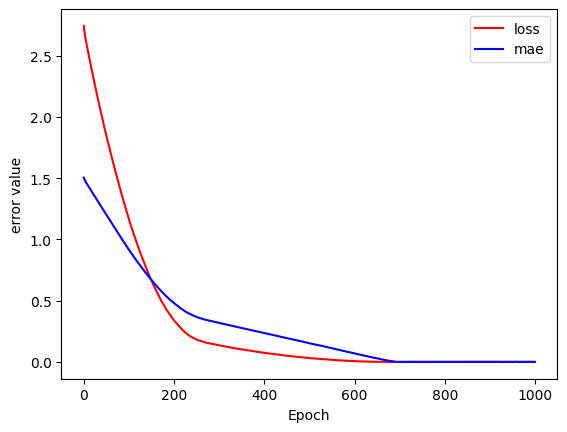

In [30]:
plt.plot(hist.history['loss'], 'r', label='loss')
plt.plot(hist.history['mae'], 'b', label='mae')
plt.legend()
plt.xlabel('Epoch')
plt.ylabel('error value')

In [31]:
# 모델 사용
model.predict(np.array([[0],
                        [0.01],
                        [0.02]]))

1/1 [==============================] - 0s 41ms/step


array([[0.32025048],
       [0.33825186],
       [0.35625327]], dtype=float32)

In [32]:
model.save('model/after_learning.h5')